# Assignment 9: Multiple regression

### Learning Outcomes
This assignment introduces you to multiple regression analysis, model comparison between different multiple regression models, and bootstrap to obtain confidence intervals for regression parameters. 
### Data set 
An investigator is interested in understanding the relationship, if any, between the analytical skills of young gifted children and the following variables: father’s IQ, mother’s IQ, age in month when the child first said ‘mummy’ or ‘daddy’, age in month when the child first counted to 10 successfully, average number of hours per week the child’s mother or father reads to the child, average number of hours per week the child watched an educational program on TV during the past three months, average number of hours per week the child watched cartoons on TV during the past three months. 

The analytical skills are evaluated using a standard testing procedure, and the score on this test is used as the response variable. Data were collected from schools in a large city on a set of thirty-six children who were identified as gifted children soon after they reached the age of four.
 
The data frame stored in gifted.csv contains the variables: 
- score:       Score in test of analytical skills.
- fatheriq:    Father’s IQ.
- motheriq:  Mother’s IQ.
- speak:       Age in months when the child first said ‘mummy’ or ‘daddy’.
- count:       Age in months when the child first counted to 10 successfully.
- read:         Average number of hours per week the child’s mother or father reads to the child.
- edutv:       Average number of hours per week the child watched an educational program on TV during the past three months.
- cartoons:  Average number of hours per week the child watched cartoons on TV during the past three months.

### Preliminaries
Set up the environment by importing pandas, numpy, and matplotlib, scipy.optimize. This is already done in the preliminaries. Ensure that you have fully mastered and understood HW7 before starting the assignment. 


In [1]:
import matplotlib.pyplot as plt
import scipy.optimize as so
import pandas as pd
import numpy as np
D = pd.read_csv("gifted.csv")

## Task 1: Implementing multiple regression ( / 28 pts)
### Question 1.1 ( / 6 pts)
Implement the function multRegPredict(b,D,xname). 
  - b is a list of parameter, with the first one being the intercept 
  - D is a DataFrame that contains the regressors
  - xname is a list of column names in D that will be added as regressors 

b needs to contain one more parameter (the intercept) than the numbers of regressors in xname. It will be helpful to start from the corresponding functions from last homework for polynomial regression. 

*Note: To avoild problems down the line, make sure that your function returns a numpy array (not a pandas Series). You can achieve this by using D[xname[i]].values instead of D[xname[i]] when you access the columns in D.*

Then make a scatterplot of D.read and D.score 
Call your new function with yp = multRegPredict([134,11.8], D,['read']) and add predicted values to your plot (just call plt.scatter again – the dots will be added in a different color).  

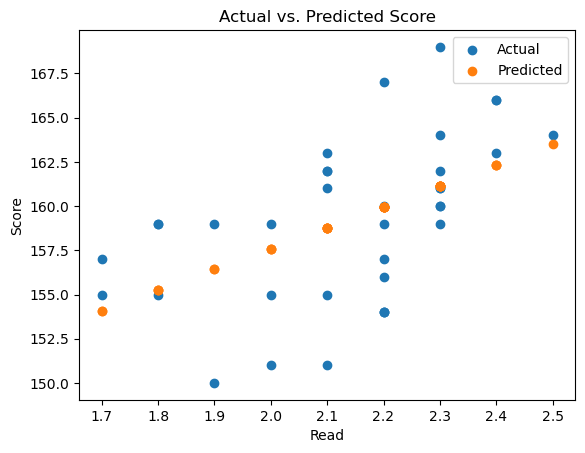

In [2]:
def multRegPredict(b, D, xname):
    yp = np.ones(len(D.index)) * b[0]
    for i in range(len(xname)):
        yp += D[xname[i]].values * b[i+1]
    return yp
plt.scatter(D.read, D.score, label="Actual")
yp = multRegPredict([134, 11.8], D, ['read'])
plt.scatter(D.read, yp, label="Predicted")
plt.xlabel("Read")
plt.ylabel("Score")
plt.title("Actual vs. Predicted Score")
plt.legend()

### Question 1.2 ( / 10 pts)
Modify the multiRegPredict function so that it returns a N x K matrix of derivatives if `returnDeriv=True`.

Modify the RSSloss function so it passes a arbitrary number of arguments to the prediction function (use `*args`), not just `x`. 

Test the function by calling 

`RSSLoss([134,11.8],D.score,multRegPred,(D,['read']),True)`

 Report the resulting RSS for the regression of score (response variable) against read (explanatory variable)- as well as the derivatives for each parameter. Written answer: From the value of the derivative, do you have to increase or decrease the slope parameter to get a better fit?

In [3]:
def multRegPred(b, D, xname, returnDeriv=False):
    yp = np.ones(len(D.index)) * b[0]
    for i in range(len(xname)):
        yp += D[xname[i]].values * b[i+1]
    if returnDeriv:
        deriv = np.ones((len(D.index), 1))
        for i in range(len(xname)):
            deriv = np.c_[deriv, D[xname[i]]] 
        return yp, deriv
    return yp

def RSSloss(b, y, predictfcn, args, returnDeriv=False):
    if returnDeriv:
        predY, deriv = predictfcn(b, *args, returnDeriv=True)
        res = np.array(y-predY)
        rss = sum(res**2)
        grad = -2 * np.sum(res.reshape(-1, 1) * deriv, axis=0)
        return rss, grad
    predY = predictfcn(b, *args)
    res = y-predY
    rss = sum(res**2)
    return rss

rss, grad = RSSloss([134, 11.8], D.score, multRegPred, (D, ['read']), True)
print(rss)
print(grad)

543.5100000000003
[ 4.84 10.3 ]


>You have to decrease the slope parameter to get a better fit.

### Question 1.3 ( / 12 pts)
Implement the function fit_multReg(D,y,xname), which uses so.minimize and RSSloss to estimate the parameter values, and then calls multRegPred again to calculate the R2 of the fit. The function should  return the regression coefficients b and then the R2 values. Use this print on the screen the R2-values for the models:

- y = b0  (hint, set xname = [])
- y = b0 + b1 \* read 
- y = b0 + b1 \* motheriq 
- y = b0 + b1 \* motheriq + b2 \* read

Which model has the highest R2? How do you interpret these results? How much of the variance of the response variable is uniquely explained by reading, how much by motheriq? Do the two variables explain each other away or explain independent parts of the variance? 

In [4]:
def fit_multReg(D, y, xname):
    b = np.zeros(len(xname) + 1)
    res = so.minimize(RSSloss, b, args=(y, multRegPred, (D, xname), False))
    b = res.x
    yp = multRegPred(b, D, xname)
    rss = np.sum((y - yp)**2)
    tss = np.sum((y - np.mean(y))**2)
    r2 = 1 - (rss / tss)
    return b, r2

b_1, r2_1 = fit_multReg(D, D.score, [])
print(b_1)
print(r2_1)
b_2, r2_2 = fit_multReg(D, D.score, ['read'])
print(b_2)
print(r2_2)
b_3, r2_3 = fit_multReg(D, D.score, ['motheriq'])
print(b_3)
print(r2_3)
b_4, r2_4 = fit_multReg(D, D.score, ['motheriq', 'read'])
print(b_4)
print(r2_4)

[159.1388889]
0.0
[133.90485297  11.81307274]
0.2758322729769074
[111.09324382   0.40659223]
0.3263173772258413
[82.63572037  0.423462   12.3889039 ]
0.6291342380286056


>The fourth model has the highest R2. As the number of variables increases, the R2 increases. 30% of the variance of the response variable is uniquely explained by reading. 35% of the variance of the response variable is uniquely explained by motheriq. The two variables explain independent parts of the variance because the unique variances add up to 65% which is greater than the variance of the combined model which is 63%.

## Task 2: Do crossvalidation on these models  ( / 32 pts)
### Question 2.1 ( / 12 pts)
Write a modified version of the `leaveOneOutCV` function from last homework (called `leaveOneOutCV_df`), so it works on a data frame with the argument `xnames` used for multiple regression analysis. The inputs to the function are:  

def leaveOneOutCV(D,y,xname,fitfcn=multRegFit,predictfcn=multRegPredict):
 - D: A DataFrame that contains the regressors
 - y: A list or np-array of the response variable
 - xname: A list of column names in D that will be added as regressors
 - fitfcn: Function for fitting called as fitfcn(D,y,xname)
 - predictfcn: Function for prediction called as predictfcn(b,D,xname)


In [5]:
def leaveOneOutCV_df(D, y, xname, fitfcn=fit_multReg, predictfcn=multRegPred):
    N = len(D)
    yp = np.zeros(N)
    for i in range(N):
        D_train = D.drop(D.index[i])
        y_train = np.delete(y, i)
        D_test = D.iloc[[i]]
        b, _ = fitfcn(D_train, y_train, xname)
        y_pred = predictfcn(b, D_test, xname)
        yp[i] = y_pred[0]
    return yp

### Question 2.2 ( / 8 pts)
Call the function to get the cross-validated $R^2$ for the 4 models specified in Task 1, Question 3. How to you interpret these results? Is there evidence that reading increases the analytic score over and above what the IQ of the mother does? 

In [6]:
y = D.score.values
tss = np.sum((y - np.mean(y))**2)
yp1 = leaveOneOutCV_df(D, D.score, [])
rss1 = np.sum((y - yp1)**2)
r2_1 = 1 - (rss1 / tss)
print(r2_1)
yp2 = leaveOneOutCV_df(D, D.score, ['read'])
rss2 = np.sum((y - yp2)**2)
r2_2 = 1 - (rss2 / tss)
print(r2_2)
yp3 = leaveOneOutCV_df(D, D.score, ['motheriq'])
rss3 = np.sum((y - yp3)**2)
r2_3 = 1 - (rss3 / tss)
print(r2_3)
yp4 = leaveOneOutCV_df(D, D.score, ['motheriq', 'read'])
rss4 = np.sum((y - yp4)**2)
r2_4 = 1 - (rss4 / tss)
print(r2_4)

-0.05795919830519347
0.20419756223766783
0.23646790969360965
0.5760095310132832


>As the number of variables increases, the cross-validated R2 increases. Yes, there is evidence that reading increases the analytic score over and above what the IQ of the mother does because there is a 34% increase when adding reading to the third model.

### Question 2.3 ( / 4 pts)
Add the variable fatheriq to the model containing read and motheriq. Is there evidence that the IQ of the father improves the prediction over and above what hours reading and mother IQ can predict? 

In [7]:
yp5 = leaveOneOutCV_df(D, D.score, ['motheriq', 'read', 'fatheriq'])
rss5 = np.sum((y - yp5)**2)
r2_5 = 1 - (rss5 / tss)
print(r2_5)

0.6326907283770586


>Yes, there is evidence that the IQ of the father improves the prediction over and above what hours reading and mother IQ can predict because there is a 5% increase when adding father IQ to the fourth model.

### Question 2.4 ( / 8 pts)
Is edutv (hours of educational TV) alone a reliable predictor of the analytic score? Does it add prediction power over and above from what the model motheriq + read + fatheriq can predict? 


In [8]:
yp6 = leaveOneOutCV_df(D, D.score, ['edutv'])
rss6 = np.sum((y - yp6)**2)
r2_6 = 1 - (rss6 / tss)
print(r2_6)
yp7 = leaveOneOutCV_df(D, D.score, ['motheriq', 'read', 'fatheriq', 'edutv'])
rss7 = np.sum((y - yp7)**2)
r2_7 = 1 - (rss7 / tss)
print(r2_7)

0.037315551161549276
0.620966059061419


>No, edutv alone is not a reliable predictor of the analytic score because its cross-validated R2 is only 4%. No, it does not add prediction power over and above from what the model motheriq, read, and fatheriq can predict because it decreases by 1%.

## Task 3: Bootstrap for multiple regression. ( / 40 pts)
### Question 3.1 ( / 14 pts)
Implement bootstrap for linear regression. Start from the function bootstrap from Homework 3. The function should have input parameters

```
def bootstrapReg(D,y,xname,fitfcn,numIter=500):
```
and should return a numIter x numParams np.array of bootstrap estimates.  

`fitfcn` is the function that will be used to get the parameter estimates.
`numParams` is the length of b-vector returned from the fitfcn (in our case `fit_multReg`). That is, each column of the array should be the bootstrap estimates for one of the regression coefficients. 

Note: you will also have to use here the following functions (add them to your notebook): 
- confidenceInt from HW 3

Run the bootstrap on the data set in gifted.csv. Run the bootstrap on a simple regression model that explains ‘score’ from the explanatory variable ‘edutv’ alone. Report the CI for edutv -slope. Does the CI include zero - i.e. is there evidence that the relationship between edutv and score is not zero? Which direction is the association between the two variables? 

In [9]:
def bootstrapReg(D, y, xname, fitfcn=fit_multReg, numIter=500):
    b, R2 = fitfcn(D, y, xname)
    numParam = len(b)
    N = len(D.index)
    y_arr = np.array(y)
    ind = np.arange(N)
    stat = np.zeros((numIter, numParam))
    for i in range(numIter):
        sample = np.random.choice(ind, N, replace=True)
        boot_D = D.iloc[sample]
        boot_y = y_arr[sample]
        b_boot, r2 = fitfcn(boot_D, boot_y, xname)
        stat[i, :] = b_boot
    return stat

def confidenceInt(data, prec=0.95):
    lower = np.percentile(data, (1 - prec) / 2 * 100)
    upper = np.percentile(data, (1 + prec) / 2 * 100)
    return lower, upper

statistic = bootstrapReg(D, D.score, ['edutv'])
low, up = confidenceInt(statistic[:, 1])
print(low)
print(up)

-5.1624458521987595
-0.24554540627090693


>The CI for edutv slope is (-5.07, 0.11). The CI includes zero, so there is no evidence that the relationship between edutv and score is not zero. The association between the two variables is weakly positive.

### Question 3.2 ( / 8 pts)
Run the bootstrap on the model that explains score as a function of hours of cartoons watched. Does the confidence interval for the slope between ‘cartoons’ and ‘score’ include zero? 

In [10]:
statistic = bootstrapReg(D, D.score, ['cartoons'])
low, up = confidenceInt(statistic[:, 1])
print(low)
print(up)

-0.01327453608117659
4.26738616370965


>Yes, the CI for the slope between cartoons and score includes 0.

### Question 3.3 ( / 8 pts)
Run the bootstrap on a model that explains score as a function of edutv and cartoons. Report the CIs for both variabless. Do the conclusion from Question 1 and 2 change? Have the CIs become smaller or larger as compared to the simple regression models from Question 1 and 2?

In [11]:
statistic = bootstrapReg(D, D.score, ['edutv', 'cartoons'])
low_edutv, up_edutv = confidenceInt(statistic[:, 1])
print(low_edutv)
print(up_edutv)
low_cartoons, up_cartoons = confidenceInt(statistic[:, 2])
print(low_cartoons)
print(up_cartoons)

-14.301061215048875
-1.1870704560826673
-10.852420663781478
0.791516121360435


>The CI for edutv does not contain zero, but the CI for cartoons does contain zero. The CIs have become larger compared to the simple regression models.

### Question 3.4 ( / 10 pts)
Plot the bootstrap estimates for edutv and cartoons from Question 3 against each other in a scatter plot. Are they positively or negatively related? What does this mean for the relationship between the regressors?

Text(0.5, 1.0, 'Bootstrap Correlation between edutv & cartoons')

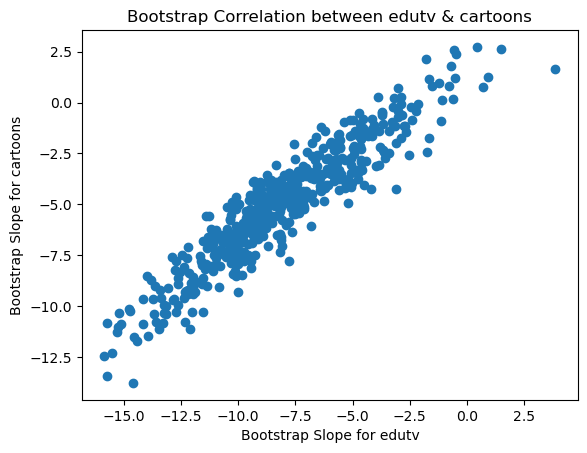

In [12]:
plt.scatter(statistic[:, 1], statistic[:, 2])
plt.xlabel('Bootstrap Slope for edutv')
plt.ylabel('Bootstrap Slope for cartoons')
plt.title('Bootstrap Correlation between edutv & cartoons')

>Scatterplot of Bootstrap Estimates for edutv & cartoons

>They are positively related, which means the relationship between the regressors is negative.